# transfer.py — interactive version

Moves funds between your two accounts: TrueMarkets (DeFi custody, on-chain) and a destination address you control (e.g. your Coinbase deposit address), via TrueMarkets' `/transfers` endpoint.

**⚠️ Running the "send" cell below submits a real on-chain transaction. There is no undo** — sending the wrong asset to the wrong network, or to an address you don't actually control, can mean the funds are unrecoverable.

This notebook never guesses or hardcodes a destination address — paste in your own, copied directly from the receiving account. To get a Coinbase deposit address: open Coinbase → the asset (e.g. USDC) → **Receive** → copy BOTH the address and the network name. The network must exactly match the `chain` you set below, or the deposit can be lost.

Run the cells in order, top to bottom — each one builds on the state from the last.

In [1]:
# 1. imports
import asyncio, sys, os
sys.path.insert(0, os.path.abspath(".."))
import aiohttp
from lib.execution import ExecutionClient
from test_scripts import transfer

KEY_FILE = "../keys/truemarkets-api-key-edd1691b.json"
BASE_URL = "https://api.truemarkets.co"

In [2]:
# 2. auth
bot = ExecutionClient(key_file=KEY_FILE, base_url=BASE_URL)
session = aiohttp.ClientSession()
await bot.authenticate(session)
print("authenticated, access_token len:", len(bot._access_token or ""))

2026-08-29 00:50:50,781  INFO      Auth: JWT minted successfully.


authenticated, access_token len: 862


## 1. Check which custody bucket holds your funds

This transfer endpoint only moves **DeFi (on-chain)** balances — if your funds are sitting in CeFi custody instead, `list-assets` below won't show anything to send.

In [3]:
unified = await bot._get(session, "/v1/conductor/balances/unified")
print("=== /balances/unified (CeFi + DeFi) ===")
for b in (unified or {}).get("data", []):
    chain = b.get("chain") or "cefi"
    print(f"  {b['symbol']:8} chain={chain:8} available={b['available']:>14} "
          f"held={b['held']:>10} tradeable={b['tradeable']}")

=== /balances/unified (CeFi + DeFi) ===
  PYUSD    chain=cefi     available= 648.329672066 held=2.6454041172 tradeable=False
  BTC      chain=cefi     available=    0.00137842 held=         0 tradeable=True
  PYUSD    chain=solana   available=      1.838928 held=         0 tradeable=True


## 2. List DeFi assets to find the `asset_id` + `chain` for what you want to send

Each chain a token exists on is its own row with its own `asset_id` — note the exact `chain` string for the network you want.

In [4]:
# change the symbol filter, or pass None to list everything
await transfer.cmd_list_assets(bot, session, None, "cefi")

SYMBOL  CHAIN         ASSET_ID
----------------------------------------------------------------------
BTC     -             b2538174-aae3-4b55-b79f-ac177c99f816
ETH     -             742f90d4-b0db-45a4-9c21-813c152aad15
PYUSD   -             810e932b-1638-4732-9127-240e64f95714


## 3. Set the transfer parameters

Edit these four values. `TO_ADDRESS` must be pasted from your own Coinbase account — never typed from memory or guessed.

In [ ]:
SYMBOL = "PYUSD"
CHAIN = "cefi"
QTY = ".0001"
PYUSD_TO_ADDRESS = "6rdoaqFD6tWrshEp3bwFtv7SQgWXXhPAonviDPSkvwCh"
BTC_TO_ADDRESS = "3PRzqbSKLubV39nEFwouMYwfGceKud1KpW"

## 4. Send — irreversible

This prints a confirmation summary and requires you to type `SEND` before anything is signed or submitted. Double-check the destination address and network before confirming.

In [ ]:
await transfer.cmd_send(bot, session, SYMBOL, CHAIN, QTY, PYUSD_TO_ADDRESS, venue = "cefi")


  CONFIRM ON-CHAIN TRANSFER — THIS CANNOT BE UNDONE
  Asset       : BTC  (b2538174-aae3-4b55-b79f-ac177c99f816)
  Chain       : None
  Quantity    : .0001 BTC
  Destination : 3PRzqbSKLubV39nEFwouMYwfGceKud1KpW
  Double-check the destination address AND network match the
  receiving account exactly before continuing.


2026-06-24 14:38:30,004  INFO      Transfer created: id=9770b836-b1d8-470b-a8b9-576807e2a4e7 status=pending
2026-06-24 14:38:30,062  INFO        status=pending  tx_hash=-   id=9770b836-b1d8-470b-a8b9-576807e2a4e7


{'id': '9770b836-b1d8-470b-a8b9-576807e2a4e7', 'status': 'pending', 'venue': 'cefi', 'asset_id': 'b2538174-aae3-4b55-b79f-ac177c99f816', 'asset_symbol': 'BTC', 'chain': None, 'network': 'bitcoin', 'to': '3PRzqbSKLubV39nEFwouMYwfGceKud1KpW', 'qty': '0.0001', 'qty_unit': 'base', 'sent': '0', 'fee': '0', 'received': '0', 'tx_hash': '', 'payloads': [], 'created_at': '2026-06-24T18:38:30.075569Z', 'updated_at': '2026-06-24T18:38:30.075569Z'}


2026-06-24 14:38:34,095  INFO        status=pending  tx_hash=-   id=9770b836-b1d8-470b-a8b9-576807e2a4e7


{'id': '9770b836-b1d8-470b-a8b9-576807e2a4e7', 'status': 'pending', 'venue': 'cefi', 'asset_id': 'b2538174-aae3-4b55-b79f-ac177c99f816', 'asset_symbol': 'BTC', 'chain': None, 'network': 'bitcoin', 'to': '3PRzqbSKLubV39nEFwouMYwfGceKud1KpW', 'qty': '0.0001', 'qty_unit': 'base', 'sent': '0', 'fee': '0', 'received': '0', 'tx_hash': '', 'payloads': [], 'created_at': '2026-06-24T18:38:30.075569Z', 'updated_at': '2026-06-24T18:38:30.075569Z'}


...

2026-06-24 14:39:22,630  INFO        status=pending  tx_hash=-   id=9770b836-b1d8-470b-a8b9-576807e2a4e7


{'id': '9770b836-b1d8-470b-a8b9-576807e2a4e7', 'status': 'pending', 'venue': 'cefi', 'asset_id': 'b2538174-aae3-4b55-b79f-ac177c99f816', 'asset_symbol': 'BTC', 'chain': None, 'network': 'bitcoin', 'to': '3PRzqbSKLubV39nEFwouMYwfGceKud1KpW', 'qty': '0.0001', 'qty_unit': 'base', 'sent': '0', 'fee': '0', 'received': '0', 'tx_hash': '', 'payloads': [], 'created_at': '2026-06-24T18:38:30.075569Z', 'updated_at': '2026-06-24T18:38:30.075569Z'}


2026-06-24 14:39:26,660  INFO        status=pending  tx_hash=-   id=9770b836-b1d8-470b-a8b9-576807e2a4e7


{'id': '9770b836-b1d8-470b-a8b9-576807e2a4e7', 'status': 'pending', 'venue': 'cefi', 'asset_id': 'b2538174-aae3-4b55-b79f-ac177c99f816', 'asset_symbol': 'BTC', 'chain': None, 'network': 'bitcoin', 'to': '3PRzqbSKLubV39nEFwouMYwfGceKud1KpW', 'qty': '0.0001', 'qty_unit': 'base', 'sent': '0', 'fee': '0', 'received': '0', 'tx_hash': '', 'payloads': [], 'created_at': '2026-06-24T18:38:30.075569Z', 'updated_at': '2026-06-24T18:38:30.075569Z'}


2026-06-24 14:39:30,662  WARNING   Stopped polling — check later with `python3 transfer.py status <id>`.


## 5. Check on a transfer later

Paste in the transfer `id` printed above (or from a previous session) to check its status without re-sending anything.

In [12]:
TRANSFER_ID = "9770b836-b1d8-470b-a8b9-576807e2a4e7"
await transfer.cmd_status(bot, session, TRANSFER_ID)

  id            9770b836-b1d8-470b-a8b9-576807e2a4e7
  status        completed
  venue         cefi
  asset_id      b2538174-aae3-4b55-b79f-ac177c99f816
  asset_symbol  BTC
  chain         None
  network       bitcoin
  to            3PRzqbSKLubV39nEFwouMYwfGceKud1KpW
  qty           0.0001
  qty_unit      base
  sent          0.00009724
  fee           0.00000276
  received      0.00009448
  tx_hash       ccc58d63c78c9f82e5d5d2dcd0dbdbea3efecf818c6a5b8074297aef03415b1d
  created_at    2026-06-24T18:38:30.075569Z
  updated_at    2026-06-24T19:58:19.913517Z


In [10]:
# cleanup
await session.close()

## Order History and Volume

2026-06-26 13:52:06,155  INFO      Auth: JWT minted successfully.


Fetching all orders (any status)...


2026-06-26 13:52:14,441  WARNING   GET /v1/conductor/orders?cursor=2026-06-26T10%3A36%3A18Z → 429 rate-limited; backing off 2.0s


2026-06-26 13:52:16,467  WARNING   GET /v1/conductor/orders?cursor=2026-06-26T10%3A36%3A18Z → 429 rate-limited; backing off 4.0s
2026-06-26 13:52:20,493  WARNING   GET /v1/conductor/orders?cursor=2026-06-26T10%3A36%3A18Z → 429 rate-limited; backing off 8.0s
2026-06-26 13:52:28,556  WARNING   GET /v1/conductor/orders?cursor=2026-06-26T10%3A36%3A18Z → 429 rate-limited; backing off 16.0s
2026-06-26 13:52:44,609  WARNING   GET /v1/conductor/orders?cursor=2026-06-26T10%3A36%3A18Z → 429 rate-limited; backing off 30.0s


2026-06-26 13:53:21,969  WARNING   GET /v1/conductor/orders?cursor=2026-06-26T04%3A12%3A50Z → 429 rate-limited; backing off 2.0s


...

2026-06-26 13:54:28,952  WARNING   GET /v1/conductor/orders?cursor=2026-06-25T21%3A17%3A20Z → 429 rate-limited; backing off 2.0s


2026-06-26 13:54:30,994  WARNING   GET /v1/conductor/orders?cursor=2026-06-25T21%3A17%3A20Z → 429 rate-limited; backing off 4.0s
2026-06-26 13:54:35,024  WARNING   GET /v1/conductor/orders?cursor=2026-06-25T21%3A17%3A20Z → 429 rate-limited; backing off 8.0s
2026-06-26 13:54:43,050  WARNING   GET /v1/conductor/orders?cursor=2026-06-25T21%3A17%3A20Z → 429 rate-limited; backing off 16.0s
2026-06-26 13:54:59,128  WARNING   GET /v1/conductor/orders?cursor=2026-06-25T21%3A17%3A20Z → 429 rate-limited; backing off 30.0s


2026-06-26 13:55:35,102  WARNING   GET /v1/conductor/orders?cursor=2026-06-17T06%3A21%3A37Z → 429 rate-limited; backing off 2.0s


2026-06-26 13:55:37,133  WARNING   GET /v1/conductor/orders?cursor=2026-06-17T06%3A21%3A37Z → 429 rate-limited; backing off 4.0s
2026-06-26 13:55:41,168  WARNING   GET /v1/conductor/orders?cursor=2026-06-17T06%3A21%3A37Z → 429 rate-limited; backing off 8.0s
2026-06-26 13:55:49,209  WARNING   GET /v1/conductor/orders?cursor=2026-06-17T06%3A21%3A37Z → 429 rate-limited; backing off 16.0s


  page 392: 11 orders

  TRADING SUMMARY
  Total Volume          : $ 82,274.02
  Buy  Volume           : $ 41,170.85  (0.689500 BTC)
  Sell Volume           : $ 41,103.17  (0.688600 BTC)
  Net BTC Position      : +0.00090000 BTC
  Avg Buy Price         : $ 59,711.16
  Avg Sell Price        : $ 59,690.93
-------------------------------------------------------
  P&L DECOMPOSITION
-------------------------------------------------------
  Net Cash from Trades  : $    -67.67
  Fees Paid             : $    -32.84
  Spread paid          : $    -13.93  ($-20.23/BTC on 0.688600 BTC)
  Open Position Cash    : $    -53.74  (+0.000900 BTC unmatched)
  Explained Total       : $   -100.52
-------------------------------------------------------
  Discrepancy           : $  +32.8437  (unexplained)


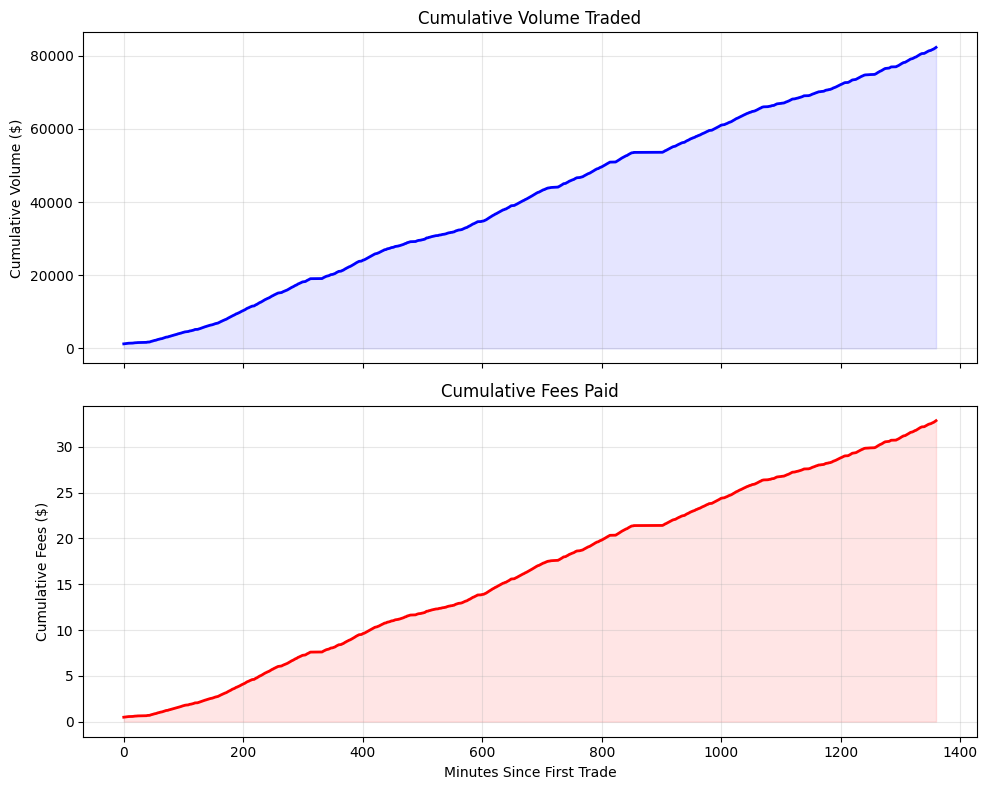

In [3]:
from datetime import datetime
import matplotlib.pyplot as plt
import urllib.parse

async def plot_volume_history():
    _bot = ExecutionClient(key_file=KEY_FILE, base_url=BASE_URL)
    async with aiohttp.ClientSession() as _session:
        await _bot.authenticate(_session)
        cursor = None
        trades = []

        buy_notional = buy_qty = 0.0
        sell_notional = sell_qty = 0.0
        total_fees = 0.0

        # Fetch all orders regardless of status — cancelled orders can have real fills
        print("Fetching all orders (any status)...")
        page = 0
        while True:
            path = "/v1/conductor/orders"
            if cursor:
                path += f"?cursor={urllib.parse.quote(cursor)}"

            data = await _bot._get(_session, path)
            if not data:
                break

            orders = data.get("data", [])
            if not orders:
                break
            page += 1
            print(f"  page {page}: {len(orders)} orders", end="\r")

            for o in orders:
                exec_qty_o = float(o.get("executed_qty", 0))
                exec_vwap  = float(o.get("executed_vwap", 0))
                fee        = float(o.get("fee", 0))
                side       = o.get("side", "")
                usd_vol    = exec_qty_o * exec_vwap

                if usd_vol > 0:
                    total_fees += fee
                    if side == "buy":
                        buy_notional += usd_vol
                        buy_qty      += exec_qty_o
                    elif side == "sell":
                        sell_notional += usd_vol
                        sell_qty      += exec_qty_o

                    created_at = o.get("created_at")
                    if created_at:
                        try:
                            time_str = created_at.split(".")[0] if "." in created_at else created_at.rstrip("Z")
                            time_str = time_str.replace("Z", "")
                            ts = datetime.strptime(time_str, "%Y-%m-%dT%H:%M:%S").timestamp()
                            trades.append((ts, usd_vol, fee))
                        except Exception as e:
                            print("Error parsing timestamp:", e)

            cursor = (data.get("pagination") or {}).get("next_cursor")
            if not cursor:
                break
        print()

        if not trades:
            print("No executed trades found to plot.")
            return

        # --- Derived metrics ---
        avg_buy_px   = buy_notional  / buy_qty   if buy_qty   > 0 else 0.0
        avg_sell_px  = sell_notional / sell_qty  if sell_qty  > 0 else 0.0
        matched_qty  = min(buy_qty, sell_qty)
        net_btc      = buy_qty - sell_qty
        net_cash     = sell_notional - buy_notional

        # Spread captured per BTC (positive = sold higher than bought = alpha)
        spread_per_btc = avg_sell_px - avg_buy_px
        spread_pnl     = spread_per_btc * matched_qty

        # Open position cash effect (unmatched side)
        if net_btc > 0:   # bought more than sold — cash spent on unmatched buys
            open_pos_cash = -net_btc * avg_buy_px
        else:             # sold more than bought — cash received from unmatched sells
            open_pos_cash = -net_btc * avg_sell_px

        # Discrepancy: what's left after fees, spread, and open position are accounted for
        # Should be ~0 if the model is complete; non-zero = data gaps or unsettled trades
        explained     = spread_pnl + open_pos_cash - total_fees
        discrepancy   = net_cash - explained

        total_volume = buy_notional + sell_notional

        print()
        print("=" * 55)
        print("  TRADING SUMMARY")
        print("=" * 55)
        print(f"  Total Volume          : ${total_volume:>10,.2f}")
        print(f"  Buy  Volume           : ${buy_notional:>10,.2f}  ({buy_qty:.6f} BTC)")
        print(f"  Sell Volume           : ${sell_notional:>10,.2f}  ({sell_qty:.6f} BTC)")
        print(f"  Net BTC Position      : {net_btc:>+.8f} BTC")
        print(f"  Avg Buy Price         : ${avg_buy_px:>10,.2f}")
        print(f"  Avg Sell Price        : ${avg_sell_px:>10,.2f}")
        print("-" * 55)
        print(f"  P&L DECOMPOSITION")
        print("-" * 55)
        print(f"  Net Cash from Trades  : ${net_cash:>+10,.2f}")
        print(f"  Fees Paid             : ${-total_fees:>+10,.2f}")
        spread_label = "captured" if spread_per_btc >= 0 else "paid"
        print(f"  Spread {spread_label:<8}      : ${spread_pnl:>+10,.2f}  (${spread_per_btc:>+,.2f}/BTC on {matched_qty:.6f} BTC)")
        print(f"  Open Position Cash    : ${open_pos_cash:>+10,.2f}  ({net_btc:>+.6f} BTC unmatched)")
        print(f"  Explained Total       : ${explained:>+10,.2f}")
        print("-" * 55)
        print(f"  Discrepancy           : ${discrepancy:>+10,.4f}  (unexplained)")
        print("=" * 55)

        # --- Plots ---
        trades.sort(key=lambda x: x[0])
        times, cum_vols, cum_fees_list = [], [], []
        current_vol = current_fee = 0.0
        for ts, vol, fee in trades:
            current_vol += vol
            current_fee += fee
            times.append(ts)
            cum_vols.append(current_vol)
            cum_fees_list.append(current_fee)

        cutoff = 200
        times = times[cutoff:]
        cum_vols = cum_vols[cutoff:]
        cum_fees_list = cum_fees_list[cutoff:]

        first_ts = times[0]
        times = [(t - first_ts) / 60.0 for t in times]

        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

        ax1.plot(times, cum_vols, color="blue", linewidth=2)
        ax1.fill_between(times, cum_vols, color="blue", alpha=0.1)
        ax1.set_title("Cumulative Volume Traded")
        ax1.set_ylabel("Cumulative Volume ($)")
        ax1.grid(True, alpha=0.3)

        ax2.plot(times, cum_fees_list, color="red", linewidth=2)
        ax2.fill_between(times, cum_fees_list, color="red", alpha=0.1)
        ax2.set_title("Cumulative Fees Paid")
        ax2.set_xlabel("Minutes Since First Trade")
        ax2.set_ylabel("Cumulative Fees ($)")
        ax2.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()

await plot_volume_history()


## Expected BTC Balance Reconciliation

In [24]:
import urllib.parse

# BTC deposited into TrueMarkets from Coinbase (hardcoded from Coinbase activity)
BTC_DEPOSITS_IN = [
    ("2026-06-25", 0.000593),  # Sent BTC from Coinbase, fee $0.28
    ("2026-06-23", 0.000204),  # Sent BTC from Coinbase, fee $0.26
]

async def fetch_order_fills(_bot, _session):
    btc_bought = btc_sold = 0.0
    buy_count = sell_count = 0
    cursor = None
    page = 0
    while True:
        path = "/v1/conductor/orders"
        if cursor:
            path += f"?cursor={urllib.parse.quote(cursor)}"
        data = await _bot._get(_session, path)
        if not data:
            break
        orders = data.get("data", [])
        if not orders:
            break
        page += 1
        print(f"  page {page}: {len(orders)} orders", end="\r")
        for o in orders:
            exec_qty = float(o.get("executed_qty", 0) or 0)
            side = o.get("side", "")
            if side == "buy" and exec_qty > 0:
                btc_bought += exec_qty
                buy_count += 1
            elif side == "sell" and exec_qty > 0:
                btc_sold += exec_qty
                sell_count += 1
        cursor = (data.get("pagination") or {}).get("next_cursor")
        if not cursor:
            break
    print()
    return btc_bought, btc_sold, buy_count, sell_count

async def calculate_expected_btc_balance():
    _bot = ExecutionClient(key_file=KEY_FILE, base_url=BASE_URL)
    async with aiohttp.ClientSession() as _session:
        await _bot.authenticate(_session)

        # --- Current BTC price ---
        async with _session.get("https://api.coinbase.com/v2/prices/BTC-USD/spot") as resp:
            price_data = await resp.json()
        btc_price = float(price_data["data"]["amount"])

        # --- Current live balance ---
        balance_data = await _bot._get(_session, "/v1/conductor/balances")
        current_btc = 0.0
        if balance_data:
            for b in balance_data.get("data", []):
                if b.get("symbol") == "BTC":
                    current_btc += float(b.get("available", 0) or 0) + float(b.get("held", 0) or 0)

        # --- All orders, any status (rate limit backoff is handled by _get) ---
        print("Fetching all orders (this may take a moment)...")
        btc_bought, btc_sold, buy_count, sell_count = await fetch_order_fills(_bot, _session)

        # --- All completed BTC transfers out ---
        print("Fetching BTC transfers out...")
        cursor = None
        btc_transferred_out = 0.0
        transfer_out_count = 0
        while True:
            path = "/v1/conductor/transfers?status=completed"
            if cursor:
                path += f"&cursor={urllib.parse.quote(cursor)}"
            data = await _bot._get(_session, path)
            if not data:
                break
            transfers = data.get("data", [])
            if not transfers:
                break
            for t in transfers:
                if t.get("asset_symbol") == "BTC":
                    btc_transferred_out += float(t.get("qty", 0) or 0)
                    transfer_out_count += 1
            cursor = (data.get("pagination") or {}).get("next_cursor")
            if not cursor:
                break

        total_deposited  = sum(amt for _, amt in BTC_DEPOSITS_IN)
        net_from_trading = btc_bought - btc_sold
        expected_btc     = total_deposited + net_from_trading - btc_transferred_out
        expected_usd     = expected_btc * btc_price
        current_usd      = current_btc * btc_price

        print()
        print("=" * 55)
        print("      EXPECTED BTC BALANCE RECONCILIATION")
        print(f"      BTC price: ${btc_price:,.2f}")
        print("=" * 55)
        for date, amt in BTC_DEPOSITS_IN:
            print(f"  Deposit In  {date}    : +{amt:.8f} BTC  (${amt * btc_price:>8.2f})")
        print(f"  Buy  Orders  ({buy_count:>4})     : +{btc_bought:.8f} BTC  (${btc_bought * btc_price:>8.2f})")
        print(f"  Sell Orders  ({sell_count:>4})     : -{btc_sold:.8f} BTC  (${btc_sold * btc_price:>8.2f})")
        print(f"  Net from Trading         :  {net_from_trading:+.8f} BTC  (${net_from_trading * btc_price:>+8.2f})")
        print(f"  Transfers Out ({transfer_out_count:>3})      : -{btc_transferred_out:.8f} BTC  (${btc_transferred_out * btc_price:>8.2f})")
        print("-" * 55)
        print(f"  Expected Final Balance   : {expected_btc:+.8f} BTC  (${expected_usd:>+8.2f})")
        print("=" * 55)
        print(f"  Current Live Balance     : {current_btc:+.8f} BTC  (${current_usd:>8.2f})")
        print("=" * 55)
        return expected_btc, current_btc, btc_price

expected_btc, current_btc, btc_price = await calculate_expected_btc_balance()


2026-06-25 16:48:24,090  INFO      Auth: JWT minted successfully.


Fetching all orders (this may take a moment)...


2026-06-25 16:48:29,441  WARNING   GET /v1/conductor/orders?cursor=2026-06-17T07%3A57%3A01Z → 429 rate-limited; backing off 2.0s
2026-06-25 16:48:31,480  WARNING   GET /v1/conductor/orders?cursor=2026-06-17T07%3A57%3A01Z → 429 rate-limited; backing off 4.0s
2026-06-25 16:48:35,508  WARNING   GET /v1/conductor/orders?cursor=2026-06-17T07%3A57%3A01Z → 429 rate-limited; backing off 8.0s
2026-06-25 16:48:43,534  WARNING   GET /v1/conductor/orders?cursor=2026-06-17T07%3A57%3A01Z → 429 rate-limited; backing off 16.0s
2026-06-25 16:48:59,590  WARNING   GET /v1/conductor/orders?cursor=2026-06-17T07%3A57%3A01Z → 429 rate-limited; backing off 30.0s


  page 102: 25 orders
Fetching BTC transfers out...

      EXPECTED BTC BALANCE RECONCILIATION
      BTC price: $59,379.29
  Deposit In  2026-06-25    : +0.00059300 BTC  ($   35.21)
  Deposit In  2026-06-23    : +0.00020400 BTC  ($   12.11)
  Buy  Orders  ( 439)     : +0.04376000 BTC  ($ 2598.44)
  Sell Orders  ( 434)     : -0.04300000 BTC  ($ 2553.31)
  Net from Trading         :  +0.00076000 BTC  ($  +45.13)
  Transfers Out (  1)      : -0.00010000 BTC  ($    5.94)
-------------------------------------------------------
  Expected Final Balance   : +0.00145700 BTC  ($  +86.52)
  Current Live Balance     : +0.00096000 BTC  ($   57.00)


## Full Portfolio Value (BTC + PYUSD/USDC)

In [26]:
async def calculate_full_portfolio():
    # Depends on expected_btc, current_btc, btc_price from the reconciliation cell above
    try:
        _expected_btc = expected_btc
        _current_btc  = current_btc
        _btc_price    = btc_price
    except NameError:
        print("Run the reconciliation cell first.")
        return

    _bot = ExecutionClient(key_file=KEY_FILE, base_url=BASE_URL)
    async with aiohttp.ClientSession() as _session:
        await _bot.authenticate(_session)

        unified = await _bot._get(_session, "/v1/conductor/balances/unified")
        balances = {}  # symbol -> total across all chains
        if unified:
            for b in unified.get("data", []):
                sym  = b.get("symbol", "")
                total = float(b.get("available", 0) or 0) + float(b.get("held", 0) or 0)
                balances[sym] = balances.get(sym, 0.0) + total

        pyusd = balances.get("PYUSD", 0.0)
        usdc  = balances.get("USDC",  0.0)
        stable_total = pyusd + usdc

        actual_total   = _current_btc  * _btc_price + stable_total
        expected_total = _expected_btc * _btc_price + stable_total

        print("=" * 55)
        print("           FULL PORTFOLIO VALUE")
        print(f"           BTC price: ${_btc_price:,.2f}")
        print("=" * 55)
        print(f"  {'Asset':<10} {'Actual':>18}  {'Expected':>18}")
        print("-" * 55)
        print(f"  {'BTC':<10} {_current_btc:>12.8f} BTC  {_expected_btc:>12.8f} BTC")
        print(f"  {'BTC (USD)':<10} {'$'+f'{_current_btc*_btc_price:.2f}':>18}  {'$'+f'{_expected_btc*_btc_price:.2f}':>18}")
        if pyusd:
            print(f"  {'PYUSD':<10} {'$'+f'{pyusd:.2f}':>18}  {'$'+f'{pyusd:.2f}':>18}")
        if usdc:
            print(f"  {'USDC':<10} {'$'+f'{usdc:.2f}':>18}  {'$'+f'{usdc:.2f}':>18}")
        print("=" * 55)
        print(f"  {'TOTAL':<10} {'$'+f'{actual_total:.2f}':>18}  {'$'+f'{expected_total:.2f}':>18}")
        print("=" * 55)

await calculate_full_portfolio()


2026-06-25 16:51:23,336  INFO      Auth: JWT minted successfully.


           FULL PORTFOLIO VALUE
           BTC price: $59,379.29
  Asset                  Actual            Expected
-------------------------------------------------------
  BTC          0.00096000 BTC    0.00145700 BTC
  BTC (USD)              $57.00              $86.52
  PYUSD                  $93.69              $93.69
  TOTAL                 $150.69             $180.21
